In [12]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# الاتصال بقاعدة البيانات وسحب الداتا بـ SQL query
conn = sqlite3.connect('ecommerce_analytics.db')
query = "SELECT * FROM customers_behavior"
df = pd.read_sql_query(query, conn)
conn.close()

# عرض أول 5 صفوف للتأكد
df.head()

,Customer_ID,Gender,Age,City,Membership_Type,Total_Spend,Items_Purchased,Average_Rating,Discount_Applied,Days_Since_Last_Purchase,Satisfaction_Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,1,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,0,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,1,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,0,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,1,55,Unsatisfied


In [13]:
# عمل نسخة من الداتا للشغل
rfm = df.copy()

# تقسيم العملاء لدرجات من 1 لـ 5 بناءً على الـ Recency (الأقل في الأيام هو الأفضل، عشان كده بنعكس الـ labels)
rfm['R_Score'] = pd.qcut(rfm['Days_Since_Last_Purchase'], q=5, labels=[5, 4, 3, 2, 1])

# تقسيم بناءً على الـ Frequency والـ Monetary (الأعلى هو الأفضل)
rfm['F_Score'] = pd.qcut(rfm['Items_Purchased'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Total_Spend'], q=5, labels=[1, 2, 3, 4, 5])

# دمج الدرجات في كود واحد
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# عرض عينة من الداتا بالدرجات الجديدة
rfm[['Customer_ID', 'Days_Since_Last_Purchase', 'Items_Purchased', 'Total_Spend', 'RFM_Score']].head()

,Customer_ID,Days_Since_Last_Purchase,Items_Purchased,Total_Spend,RFM_Score
0,101,25,14,1120.20,344
1,102,18,11,780.50,423
2,103,42,9,510.75,112
3,104,12,19,1480.30,555
4,105,55,13,720.40,133


C:\Users\DELL\AppData\Local\Temp\ipykernel_16176\256179822.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm, y='Segment', order=rfm['Segment'].value_counts().index, palette='viridis')


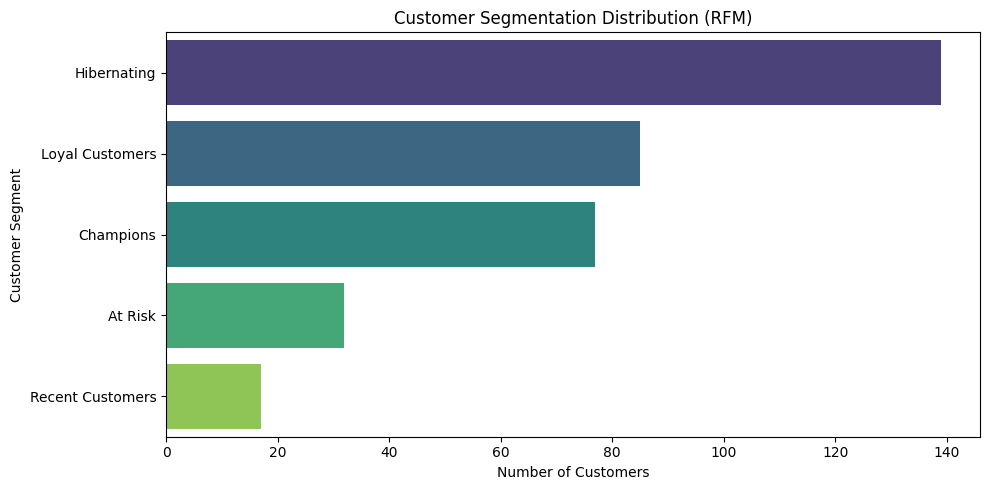

In [14]:
# دالة لتحديد فئة العميل بالإنجليزية لتجنب مشاكل الخطوط العربية المعكوسة
def segment_customer(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    
    if r >= 4 and f >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'Recent Customers'
    elif r <= 2 and f >= 4:
        return 'At Risk'
    else:
        return 'Hibernating'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

# رصد توزيع العملاء على الشرائح
plt.figure(figsize=(10, 5))
sns.countplot(data=rfm, y='Segment', order=rfm['Segment'].value_counts().index, palette='viridis')
plt.title('Customer Segmentation Distribution (RFM)')
plt.xlabel('Number of Customers')
plt.ylabel('Customer Segment')
plt.tight_layout()
plt.show()

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. عمل نسخة وتنظيف أي قيم مفقودة في عمود Satisfaction_Level
ml_df = rfm.copy()
ml_df = ml_df.dropna(subset=['Satisfaction_Level']) # السطر ده هيمسح أي صف ملوش تقييم رضا

# 2. تحويل الأعمدة النصية لأرقام باستخدام LabelEncoder
le = LabelEncoder()
ml_df['Gender'] = le.fit_transform(ml_df['Gender'])
ml_df['City'] = le.fit_transform(ml_df['City'])
ml_df['Membership_Type'] = le.fit_transform(ml_df['Membership_Type'])
ml_df['Discount_Applied'] = le.fit_transform(ml_df['Discount_Applied'])
ml_df['Segment'] = le.fit_transform(ml_df['Segment'])

# 3. تحديد الـ Features والـ Target بعد التنظيف
X = ml_df[['Gender', 'Age', 'City', 'Membership_Type', 'Total_Spend', 
          'Items_Purchased', 'Average_Rating', 'Discount_Applied', 
          'Days_Since_Last_Purchase', 'Segment']]
y = ml_df['Satisfaction_Level']

# 4. تقسيم الداتا لـ (Train) و (Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("تم تنظيف البيانات وتجهيزها بنجاح ومن غير أي قيم مفقودة! 🎯")

تم تنظيف البيانات وتجهيزها بنجاح ومن غير أي قيم مفقودة! 🎯


In [16]:
# 1. بناء الموديل وتدريبه
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 2. التنبؤ على بيانات الاختبار
y_pred = model.predict(X_test)

# 3. طباعة مدى دقة الموديل (Accuracy)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")
print("Detailed Classification Report:\n")
print(classification_report(y_test, y_pred))

Model Accuracy: 98.57%

Detailed Classification Report:

              precision    recall  f1-score   support

     Neutral       1.00      0.96      0.98        25
   Satisfied       0.96      1.00      0.98        26
 Unsatisfied       1.00      1.00      1.00        19

    accuracy                           0.99        70
   macro avg       0.99      0.99      0.99        70
weighted avg       0.99      0.99      0.99        70

